# Market Regime Detection using K-Means Clustering

## Objective

The objective of this notebook is to identify hidden market regimes within Bitcoin price behavior using unsupervised machine learning.

After transforming the original financial features through Principal Component Analysis (PCA), we apply K-Means clustering to group observations with similar characteristics.

These clusters may represent different market conditions such as:

- Bull Markets
- Bear Markets
- Sideways Markets
- Transitional Periods

Unlike supervised learning, no regime labels are provided to the model. Instead, the algorithm discovers patterns directly from the data.

The resulting clusters will serve as the foundation for the market regime detection system developed in this project.

Clustering is performed on the PCA-transformed dataset rather than the original engineered features.

The PCA components provide a compact representation of market behavior by combining information from returns, volatility, and momentum while reducing redundancy between variables.

Using the PCA feature space can improve cluster separation and facilitate the identification of meaningful market regimes.

-----

## Load PCA Dataset

In this section, we load the dataset generated during the PCA stage.

This dataset contains the principal components that will be used as inputs for the clustering algorithm.

The objective is to verify that the PCA transformation was successfully saved and can be loaded correctly for the market regime detection process.

In [2]:
# Import libraries
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os 
import sys

# Ruta absoluta a la raíz del proyecto
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [3]:
# Load PCA DataSet
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

pca_path =(
    f"{PROCESSED_DATA_PATH}/"
    f"{asset_name}_pca.csv"
)

df = pd.read_csv(pca_path)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

------

## Dataset Verification

Before applying clustering algorithms, we verify the structure of the PCA-transformed dataset.

The dataset should contain the principal components generated during the dimensionality reduction stage and will serve as the feature space used to identify potential market regimes.

In [4]:
# Vrification of the df
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 3065 entries, 2018-01-31 to 2026-06-22
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     3065 non-null   float64
 1   PC2     3065 non-null   float64
 2   PC3     3065 non-null   float64
dtypes: float64(3)
memory usage: 95.8 KB


,PC1,PC2,PC3
count,3.065000e+03,3.065000e+03,3.065000e+03
mean,-1.159124e-17,3.709195e-17,-2.318247e-17
std,1.128224e+00,1.001394e+00,8.516445e-01
min,-1.054665e+01,-1.706852e+00,-5.187152e+00
25%,-5.492385e-01,-6.763457e-01,-4.641618e-01
50%,-3.282028e-02,-2.004149e-01,-4.235113e-02
75%,5.477539e-01,4.728205e-01,4.116788e-01
max,6.087710e+00,4.982666e+00,5.821992e+00


### Interpretation

The PCA-transformed dataset contains 3,065 observations represented by three principal components (PC1, PC2, and PC3), providing a compact representation of market behavior suitable for clustering analysis.

No missing values were detected, and all principal components are stored as numerical variables, satisfying the requirements of the K-Means algorithm.

The principal components are centered around zero, which is expected after feature standardization and PCA transformation. Additionally, the decreasing standard deviations across components reflect the variance hierarchy identified during the PCA stage, where PC1 captures the largest proportion of information and PC3 captures the smallest.

Overall, the dataset appears clean, consistent, and ready for unsupervised learning. The principal component space will be used to identify potential market regimes through clustering techniques.

-----

## Clustering Workflow Overview

Clustering is an unsupervised learning technique used to identify groups of observations that exhibit similar characteristics.

In this project, clustering is applied to the PCA-transformed feature space to discover potential market regimes. Rather than using predefined labels, the algorithm will automatically group observations based on their similarity in terms of the principal components extracted during the dimensionality reduction stage.

The clustering workflow consists of the following steps:

1. Determine an appropriate number of clusters.
2. Train the clustering model.
3. Assign each observation to a cluster.
4. Visualize cluster separation in PCA space.
5. Interpret the resulting market regimes.

The ultimate objective is to identify recurring patterns of market behavior that may correspond to distinct financial conditions such as bullish, bearish, or high-volatility environments.

### Methods of clustering 
The Elbow Method and Silhouette Score provide complementary perspectives on clustering quality.

The Elbow Method evaluates cluster compactness by measuring the within-cluster sum of squares, while the Silhouette Score evaluates how well separated the clusters are from one another.

Using both metrics reduces the risk of selecting a cluster configuration that is either overly fragmented or insufficiently distinct, leading to a more robust identification of market regimes.

-----

## Cluster Selection Analysis

Before training the final clustering model, multiple values of K will be evaluated to determine an appropriate number of clusters.

The evaluation will be based on both the Elbow Method and the Silhouette Score. Together, these metrics provide complementary information regarding cluster compactness and cluster separation.

The objective is to identify candidate cluster configurations that can later be analyzed from a financial perspective.

In [5]:
# Import clustering tools
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
# Store evaluation metrics

inertia_scores = []
silhouette_scores = []
k_values = []

In [7]:
# Evaluate different cluster configurations
for k in range(MIN_CLUSTERS, MAX_CLUSTERS + 1):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(df)

    inertia_scores.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(df, cluster_labels))

    k_values.append(k)

In [8]:
# Create evaluation table
evaluation_df = pd.DataFrame({
    "K": k_values,
    "Inertaia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

evaluation_df

,K,Inertaia,Silhouette Score
0,2,7057.932230,0.298920
1,3,5503.171739,0.310379
2,4,4709.181632,0.318086
3,5,4235.243400,0.307491
4,6,3790.364363,0.248393
5,7,3499.990021,0.247846
6,8,3242.453492,0.229861
7,9,3016.390171,0.245322
8,10,2834.339394,0.248465


### Interpretation

The clustering evaluation was performed using both the Elbow Method (Inertia) and the Silhouette Score across cluster configurations ranging from K=2 to K=10.

As expected, inertia decreases monotonically as the number of clusters increases, indicating improved within-cluster compactness. However, inertia alone cannot determine the optimal number of clusters because additional clusters will almost always reduce the metric.

The Silhouette Score provides additional insight by evaluating the balance between cluster cohesion and separation. The highest score was obtained for K=4 (0.318), while K=3 and K=5 also produced competitive results.

These results suggest that the most promising cluster configurations lie between three and five clusters. Consequently, these candidate values will be further analyzed before selecting the final market regime structure.

-----

## Elbow Method Analysis

The Elbow Method is used to evaluate how cluster compactness changes as the number of clusters increases.

For each value of K, the within-cluster sum of squares (Inertia) is calculated. Lower inertia values indicate that observations are closer to their assigned centroids.

The objective is to identify a point where adding additional clusters provides diminishing improvements. This point, commonly referred to as the "elbow", represents a potential candidate for the optimal number of clusters.

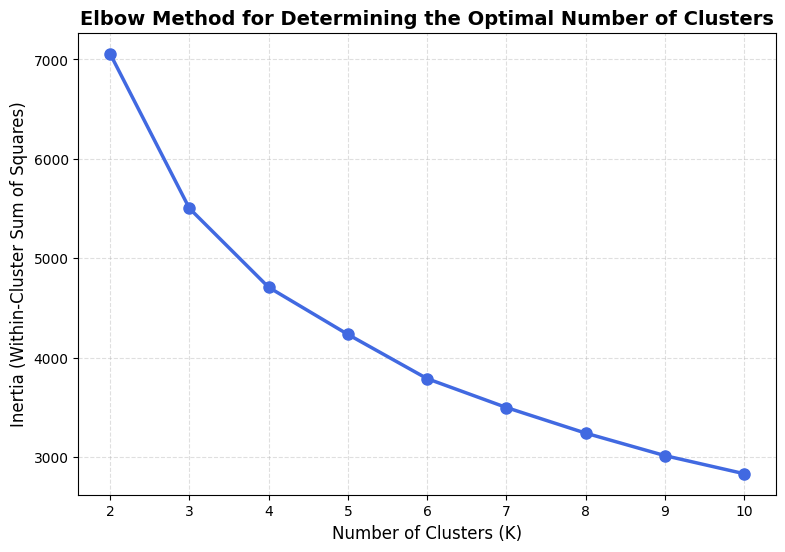

In [12]:
# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)


The inertia decreases sharply from K=2 to K=4 and then starts to flatten, suggesting a potential elbow around K=4. Let's take a look of it

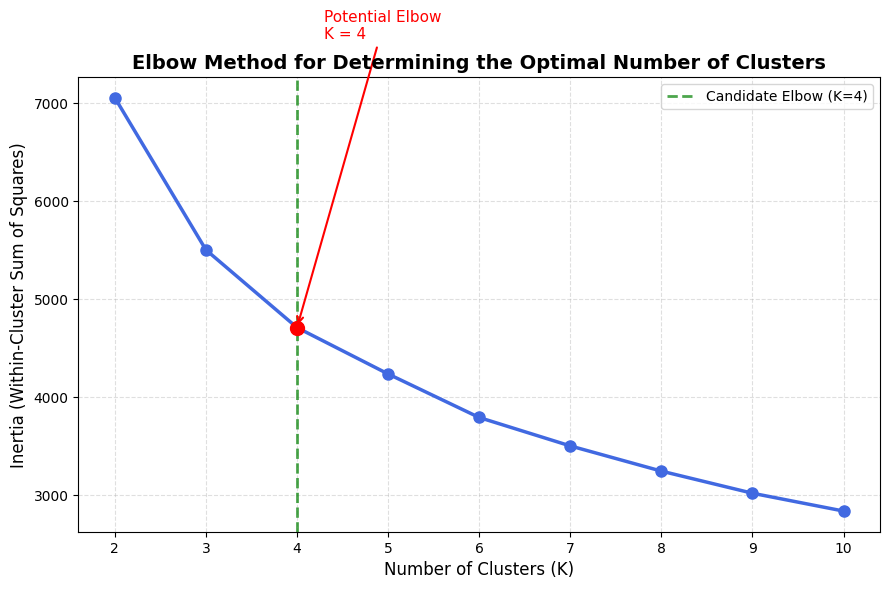

In [20]:
# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

# Highlight the candidate elbow
candidate_k = 4 
plt.axvline(
    x = candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Candidate Elbow (K=4)"
)

plt.scatter(
    candidate_k,
    inertia_scores[candidate_k - MIN_CLUSTERS],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    "Potential Elbow\nK = 4",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0] + 600),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    fontsize=11,
    color="red"
)

plt.legend()

plt.tight_layout()
plt.show()

------

----

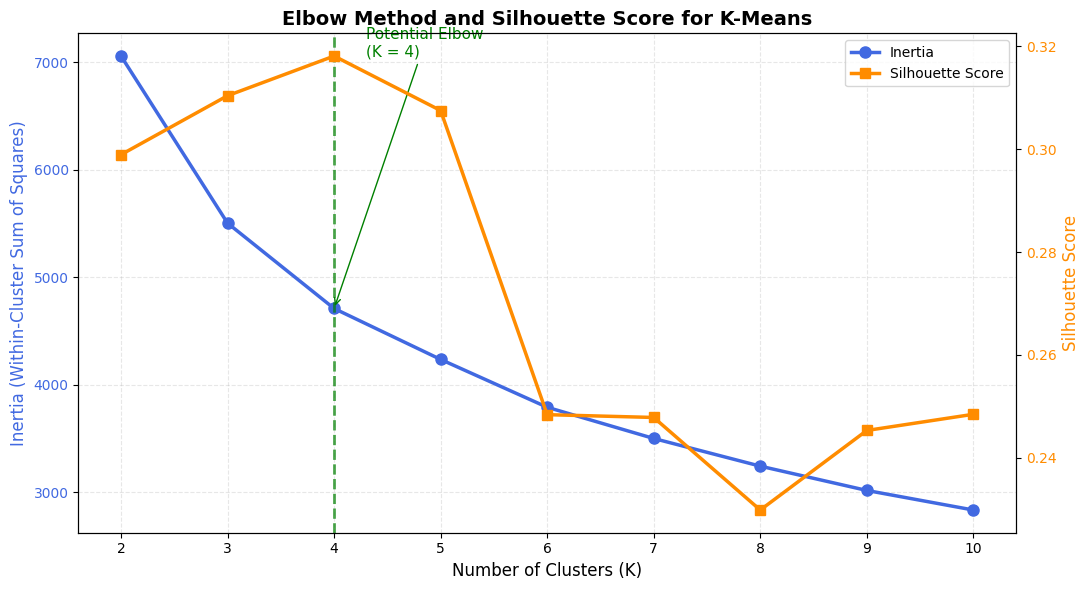

In [ ]:
# Plot Elbow Method and Silhouette Score

fig, ax1 = plt.subplots(figsize=(11, 6))

# -------------------------
# Elbow Method (Inertia)
# -------------------------
ax1.plot(
    k_values,
    inertia_scores,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="royalblue",
    label="Inertia"
)

ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)",
               fontsize=12,
               color="royalblue")

ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.grid(True, linestyle="--", alpha=0.3)

# Highlight the proposed elbow
candidate_k = 4

ax1.axvline(
    candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

ax1.annotate(
    "Potential Elbow\n(K = 4)",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0]),
    arrowprops=dict(arrowstyle="->", color="green"),
    fontsize=11,
    color="green"
)

# -------------------------
# Silhouette Score
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    k_values,
    silhouette_scores,
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="darkorange",
    label="Silhouette Score"
)

ax2.set_ylabel(
    "Silhouette Score",
    fontsize=12,
    color="darkorange"
)

ax2.tick_params(axis="y", labelcolor="darkorange")

# -------------------------
# Legends
# -------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title(
    "Elbow Method and Silhouette Score for K-Means",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()